In [47]:
import importlib
import numpy as np
import sys
import urllib.request
sys.path.append('../')
import deep_learning.model
#importlib.reload(deep_learning.model)
#importlib.reload(deep_learning.utils)
from deep_learning.utils import train_test_split,plot_learning_curve,plot_neuron_heatmap
from deep_learning.model import Perceptron #import my implmentation

In [48]:
# Iris dataset : The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
urllib.request.urlretrieve(url, "iris.csv")  # download
data = np.genfromtxt("iris.csv", delimiter=",", dtype=str)  # read
SETOSA = "Iris-setosa"
VERSICOLOR = "Iris-versicolor"
mask = (data[:, 4] == SETOSA) | (data[:, 4] == VERSICOLOR) # first two classes
data = data[mask]
class_names = np.unique(data[:, 4]) # ['Iris-setosa', 'Iris-versicolor']

In [49]:
X = data[:, 0:4].astype(float)
y = (data[:, 4] == class_names[1]).astype(int)

In [50]:
SEED = 24
(X_train, X_test, y_train, y_test) = train_test_split(X, y, 0.1, SEED)

In [51]:
# normalization by feature
X_min, X_max = X_train.min(axis=0), X_train.max(axis=0) # row colapse
X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

In [52]:
EPOCHS = 125
LR = 0.0005
model = Perceptron(X.shape[1], lr=LR, seed=SEED)
errors = model.train(X_train, y_train, epochs=EPOCHS)
for index, epoch_error in enumerate(errors):
    print(f"Epoch: {index+1} | Errores: {epoch_error}")

Epoch: 1 | Errores: 46
Epoch: 2 | Errores: 10
Epoch: 3 | Errores: 4
Epoch: 4 | Errores: 2
Epoch: 5 | Errores: 2
Epoch: 6 | Errores: 1
Epoch: 7 | Errores: 0


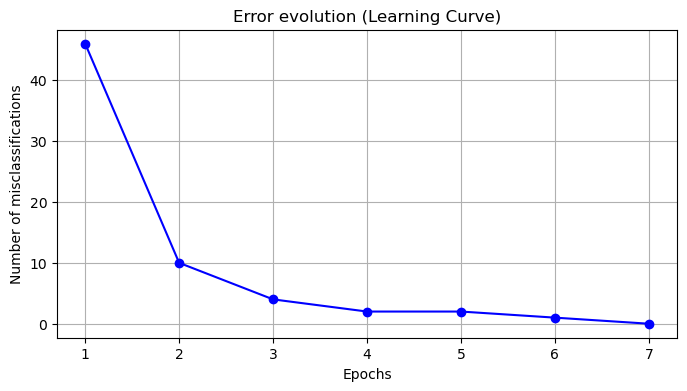

In [53]:
plot_learning_curve(errors,'Number of misclassifications')

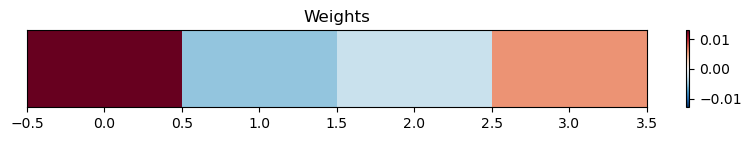

In [54]:
plot_neuron_heatmap(model)

In [55]:
for xi, yi in zip(X_test, y_test):
    pred = model.predict(xi)
    print(f"true: {class_names[yi]}  prediction: {class_names[pred]}")

true: Iris-setosa  prediction: Iris-setosa
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-setosa  prediction: Iris-setosa
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-versicolor  prediction: Iris-versicolor
true: Iris-setosa  prediction: Iris-setosa
true: Iris-setosa  prediction: Iris-setosa


In [56]:
accuracy = np.mean(model.predict(X_test) == y_test)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%
